n_qubits = 4
dim = 16
bitstrings = ['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']

SKQD blocks by timestep:
step 1:
  basis indices : [10, 12, 11, 8]
  bitstrings    : ['1010', '1100', '1011', '1000']
step 2:
  basis indices : [14, 7, 0, 6]
  bitstrings    : ['1110', '0111', '0000', '0110']
step 3:
  basis indices : [1, 2, 4, 13]
  bitstrings    : ['0001', '0010', '0100', '1101']
step 4:
  basis indices : [5, 9, 3, 15]
  bitstrings    : ['0101', '1001', '0011', '1111']

Full SKQD ordering:
[10, 12, 11, 8, 14, 7, 0, 6, 1, 2, 4, 13, 5, 9, 3, 15]

Full-space ground-state energy = -6.540106542978


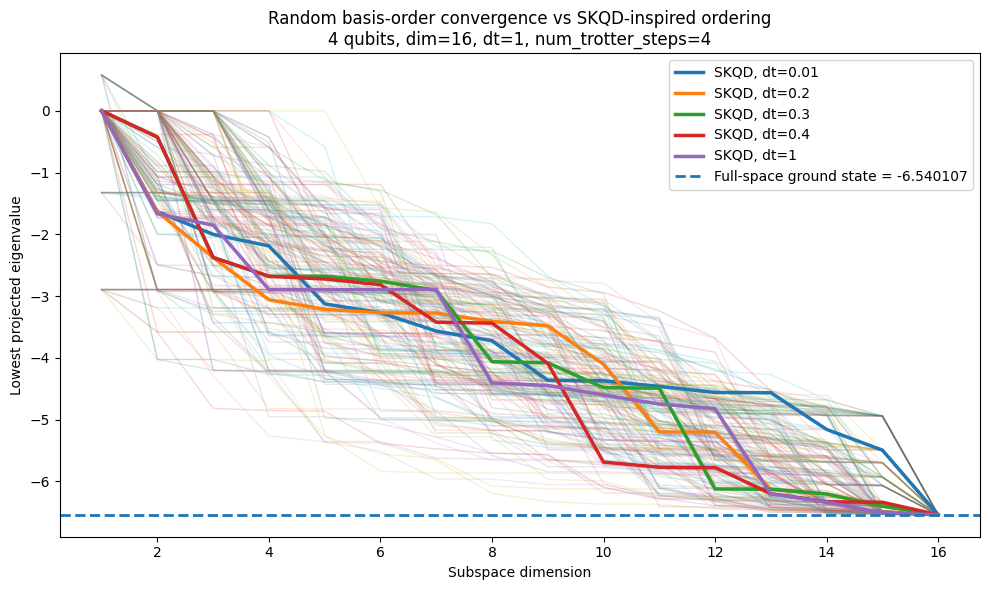

In [ ]:
import itertools
import math
from typing import Iterable, List, Tuple, Optional

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt


# ============================================================
# Random sparse Hermitian Hamiltonian
# ============================================================

def make_hermitian_sparse_random_from_qubits(
    n_qubits: int,
    density: float,
    seed: int = 42,
) -> sp.csr_matrix:
    """
    Random sparse Hermitian Hamiltonian on the computational basis
    of n_qubits, dimension 2**n_qubits.
    """
    dim = 2 ** n_qubits
    rng = np.random.default_rng(seed)

    A = sp.random(
        dim,
        dim,
        density=density,
        format="csr",
        dtype=np.complex128,
        random_state=rng,
        data_rvs=lambda n: rng.standard_normal(n) + 1j * rng.standard_normal(n),
    )

    H = A + A.conj().T
    H = 0.5 * (H + H.getH())  # enforce exact Hermiticity numerically
    return H.tocsr()


# ============================================================
# Computational basis
# ============================================================

def computational_bitstrings(n_qubits: int) -> List[str]:
    return [format(i, f"0{n_qubits}b") for i in range(2 ** n_qubits)]


# ============================================================
# Permutations and random convergence curves
# ============================================================

def exact_number_of_permutations(n_qubits: int) -> int:
    return math.factorial(2 ** n_qubits)


def permutation_iterator(
    n_states: int,
    mode: str = "sample",
    n_samples: int = 100,
    seed: int = 1234,
) -> Iterable[np.ndarray]:
    if mode == "all":
        for perm in itertools.permutations(range(n_states)):
            yield np.array(perm, dtype=int)
    elif mode == "sample":
        rng = np.random.default_rng(seed)
        base = np.arange(n_states)
        for _ in range(n_samples):
            yield rng.permutation(base)
    else:
        raise ValueError("mode must be either 'all' or 'sample'")


def convergence_curve_for_permutation_dense(
    H_dense: np.ndarray,
    perm: np.ndarray,
) -> np.ndarray:
    """
    Reorder H once by perm, then for m=1..dim compute the ground-state
    energy of the leading principal m x m block.
    """
    H_perm = H_dense[np.ix_(perm, perm)]
    dim = H_perm.shape[0]
    energies = np.empty(dim, dtype=float)

    for m in range(1, dim + 1):
        energies[m - 1] = np.linalg.eigvalsh(H_perm[:m, :m])[0]

    return energies


def all_convergence_curves_dense(
    H: sp.csr_matrix | np.ndarray,
    mode: str = "sample",
    n_samples: int = 100,
    seed: int = 1234,
) -> np.ndarray:
    if sp.issparse(H):
        H_dense = H.toarray()
    else:
        H_dense = np.asarray(H, dtype=np.complex128)

    dim = H_dense.shape[0]
    curves = []

    for perm in permutation_iterator(dim, mode=mode, n_samples=n_samples, seed=seed):
        curves.append(convergence_curve_for_permutation_dense(H_dense, perm))

    return np.vstack(curves)


def full_ground_state_energy_dense(H_dense: np.ndarray) -> float:
    return float(np.linalg.eigvalsh(H_dense)[0].real)


# ============================================================
# Trotter decomposition for a generic sparse Hermitian matrix
# ============================================================

def decompose_sparse_hermitian_into_terms(H: sp.csr_matrix):
    """
    Decompose a sparse Hermitian H into simple Hermitian terms:

      - diagonal term: h_ii |i><i|
      - off-diagonal pair term for each i<j with H_ij != 0:
            [[0, h_ij],
             [h_ij^*, 0]]
        acting on span{|i>, |j>}.

    Returns
    -------
    diag_values : ndarray, shape (dim,)
        diagonal elements H_ii
    pair_terms : list of tuples
        Each tuple is (i, j, hij) for i<j and hij = H_ij.
    """
    H_coo = H.tocoo()
    dim = H.shape[0]

    diag_values = np.zeros(dim, dtype=np.complex128)
    pair_terms = []

    for i, j, val in zip(H_coo.row, H_coo.col, H_coo.data):
        if i == j:
            diag_values[i] = val
        elif i < j:
            pair_terms.append((i, j, val))

    return diag_values, pair_terms


def apply_diagonal_term_evolution(
    psi: np.ndarray,
    diag_values: np.ndarray,
    dt: float,
) -> np.ndarray:
    """
    Apply exp(-i dt D) where D is diagonal with entries diag_values.
    """
    phases = np.exp(-1j * dt * diag_values)
    return phases * psi


def apply_pair_term_evolution(
    psi: np.ndarray,
    i: int,
    j: int,
    hij: complex,
    dt: float,
) -> None:
    """
    Apply exp(-i dt H_ij_pair) in-place on amplitudes psi[i], psi[j], where

        H_ij_pair = hij |i><j| + hij^* |j><i|.

    In the {|i>, |j>} block:
        [[0, hij],
         [hij^*, 0]]

    This 2x2 Hermitian block has norm |hij| and can be exponentiated analytically.
    """
    a = psi[i]
    b = psi[j]

    r = abs(hij)
    if r == 0.0:
        return

    c = np.cos(dt * r)
    s = np.sin(dt * r)

    # Since H_pair^2 = r^2 I on the 2D subspace,
    # exp(-i dt H_pair) = cos(dt r) I - i sin(dt r) (H_pair / r)
    psi[i] = c * a - 1j * s * (hij / r) * b
    psi[j] = c * b - 1j * s * (np.conjugate(hij) / r) * a


def trotter_step_first_order(
    psi: np.ndarray,
    diag_values: np.ndarray,
    pair_terms: List[Tuple[int, int, complex]],
    dt: float,
) -> np.ndarray:
    """
    One first-order Lie-Trotter step:
        exp(-i dt H) ~ [prod_pairs exp(-i dt H_pair)] exp(-i dt D)

    Order is fixed by the sparse storage traversal.
    """
    psi_new = apply_diagonal_term_evolution(psi.copy(), diag_values, dt)

    for i, j, hij in pair_terms:
        apply_pair_term_evolution(psi_new, i, j, hij, dt)

    # numerical renormalization
    norm = np.linalg.norm(psi_new)
    if norm > 0:
        psi_new /= norm

    return psi_new


# ============================================================
# SKQD-inspired ordering from Trotterized evolution
# ============================================================

def sampling_schedule(total_states: int, num_steps: int) -> List[int]:
    """
    Split total_states across num_steps as evenly as possible.
    Example: 16 states across 5 steps -> [4, 3, 3, 3, 3]
    """
    base = total_states // num_steps
    rem = total_states % num_steps
    return [base + (1 if k < rem else 0) for k in range(num_steps)]


def skqd_bitstring_order_from_trotter(
    H: sp.csr_matrix,
    n_qubits: int,
    dt: float = 0.1,
    num_trotter_steps: int = 4,
    initial_basis_index: int = 0,
) -> Tuple[np.ndarray, List[List[int]], List[np.ndarray]]:
    """
    Build a bitstring ordering by:
      1. Start from a computational basis state |initial_basis_index>
      2. Apply one Trotter step
      3. Sample the quota of as-yet-unsampled basis states with largest amplitude
      4. Repeat for num_trotter_steps steps until all basis states are sampled

    Returns
    -------
    final_order : ndarray, shape (2^N,)
        Concatenated basis-state ordering
    blocks : list of lists
        blocks[t] are the indices sampled at timestep t
    states : list of ndarray
        evolved state after each Trotter step
    """
    dim = 2 ** n_qubits
    diag_values, pair_terms = decompose_sparse_hermitian_into_terms(H)

    psi = np.zeros(dim, dtype=np.complex128)
    psi[initial_basis_index] = 1.0

    quotas = sampling_schedule(dim, num_trotter_steps)

    unsampled = set(range(dim))
    blocks: List[List[int]] = []
    states: List[np.ndarray] = []

    for step in range(num_trotter_steps):
        psi = trotter_step_first_order(psi, diag_values, pair_terms, dt)
        states.append(psi.copy())

        quota = quotas[step]

        probs = np.abs(psi) ** 2
        ranking = np.argsort(-probs)  # descending probability

        chosen = []
        for idx in ranking:
            if idx in unsampled:
                chosen.append(int(idx))
                if len(chosen) == quota:
                    break

        # Fallback, in case numerical degeneracies or bookkeeping issues occur
        if len(chosen) < quota:
            remaining = [idx for idx in range(dim) if idx in unsampled and idx not in chosen]
            chosen.extend(remaining[: quota - len(chosen)])

        for idx in chosen:
            unsampled.remove(idx)

        blocks.append(chosen)

    # If anything somehow remains unsampled, append at end in descending final amplitude
    if unsampled:
        probs = np.abs(psi) ** 2
        leftover = sorted(list(unsampled), key=lambda x: -probs[x])
        blocks.append(leftover)

    final_order = np.array([idx for block in blocks for idx in block], dtype=int)

    if len(final_order) != dim:
        raise RuntimeError("Final SKQD ordering does not contain exactly all basis states once.")

    if len(set(final_order.tolist())) != dim:
        raise RuntimeError("Final SKQD ordering contains duplicates.")

    return final_order, blocks, states


# ============================================================
# Plotting
# ============================================================

def plot_convergence_curves_with_skqd(
    random_curves: np.ndarray,
    skqd_curves: list[np.ndarray],
    e0_full: float,
    title: str,
    alpha_random: float = 0.15,
    timesteps: list = None,
):
    x = np.arange(1, random_curves.shape[1] + 1)

    plt.figure(figsize=(10, 6))

    for i in range(random_curves.shape[0]):
        plt.plot(x, random_curves[i], alpha=alpha_random, linewidth=1)

    for i in range(len(skqd_curves)): 
        skqd_curve = skqd_curves[i]
        plt.plot(
            x,
            skqd_curve,
            linewidth=2.5,
            label=f"SKQD, dt={timesteps[i]}" if timesteps is not None else "SKQD",
        )

    plt.axhline(
        e0_full,
        linestyle="--",
        linewidth=2,
        label=f"Full-space ground state = {e0_full:.6f}",
    )

    plt.xlabel("Subspace dimension")
    plt.ylabel("Lowest projected eigenvalue")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# End-to-end example
# ============================================================

if __name__ == "__main__":
    # --------------------------------------------------------
    # Parameters
    # --------------------------------------------------------
    n_qubits = 4
    density = 0.2
    hamiltonian_seed = 42

    # Random baseline curves
    n_samples = 200
    permutation_seed = 7

    # SKQD / Trotter parameters
    dt = 0.1
    num_trotter_steps = 4
    initial_basis_index = 0  # |0000>

    # --------------------------------------------------------
    # Build Hamiltonian and basis
    # --------------------------------------------------------
    H = make_hermitian_sparse_random_from_qubits(
        n_qubits=n_qubits,
        density=density,
        seed=hamiltonian_seed,
    )
    H_dense = H.toarray()
    bitstrings = computational_bitstrings(n_qubits)

    print(f"n_qubits = {n_qubits}")
    print(f"dim = {2**n_qubits}")
    print("bitstrings =", bitstrings)

    # --------------------------------------------------------
    # Random permutation convergence curves
    # --------------------------------------------------------
    random_curves = all_convergence_curves_dense(
        H_dense,
        mode="sample",
        n_samples=n_samples,
        seed=permutation_seed,
    )

    # --------------------------------------------------------
    # SKQD-inspired ordering from Trotterized evolution
    # --------------------------------------------------------
    # skqd_order, skqd_blocks, trotter_states = skqd_bitstring_order_from_trotter(
    #     H=H,
    #     n_qubits=n_qubits,
    #     dt=dt,
    #     num_trotter_steps=num_trotter_steps,
    #     initial_basis_index=initial_basis_index,
    # )

    # skqd_bitstrings = [bitstrings[i] for i in skqd_order]
    skqd_curves = []

    dt_list = [0.01, 0.2, 0.3, 0.4, 1]
    for dt in dt_list:
        skqd_order, skqd_blocks, trotter_states = skqd_bitstring_order_from_trotter(
            H=H,
            n_qubits=n_qubits,
            dt=dt,
            num_trotter_steps=num_trotter_steps,
            initial_basis_index=initial_basis_index,
        )
        skqd_curves.append(convergence_curve_for_permutation_dense(H_dense, skqd_order))

    # skqd_curve = convergence_curve_for_permutation_dense(H_dense, skqd_order)

    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------
    e0_full = full_ground_state_energy_dense(H_dense)

    print("\nSKQD blocks by timestep:")
    for t, block in enumerate(skqd_blocks, start=1):
        print(f"step {t}:")
        print("  basis indices :", block)
        print("  bitstrings    :", [bitstrings[i] for i in block])

    print("\nFull SKQD ordering:")
    print(skqd_order.tolist())
    # print(skqd_bitstrings)

    print(f"\nFull-space ground-state energy = {e0_full:.12f}")
    # print(f"SKQD final-point error = {abs(skqd_curve[-1] - e0_full):.3e}")

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    plot_convergence_curves_with_skqd(
        random_curves=random_curves,
        skqd_curves=skqd_curves,
        e0_full=e0_full,
        title=(
            f"Random basis-order convergence vs SKQD-inspired ordering\n"
            f"{n_qubits} qubits, dim={2**n_qubits}, dt={dt}, "
            f"num_trotter_steps={num_trotter_steps}"
        ),
        alpha_random=0.18,
        timesteps=dt_list,
    )

# Hamiltonian with sparse groundstate

Bitstring-assignment summary:
  step 0: 1 bitstrings
    indices    : [0]
    bitstrings : ['0000']
  step 1: 2 bitstrings
    indices    : [1, 2]
    bitstrings : ['0001', '0010']
  step 2: 2 bitstrings
    indices    : [12, 5]
    bitstrings : ['1100', '0101']
  step 3: 2 bitstrings
    indices    : [7, 8]
    bitstrings : ['0111', '1000']
  step 4: 2 bitstrings
    indices    : [6, 3]
    bitstrings : ['0110', '0011']
  step 5: 2 bitstrings
    indices    : [4, 9]
    bitstrings : ['0100', '1001']
  step 6: 1 bitstrings
    indices    : [10]
    bitstrings : ['1010']
  step 7: 1 bitstrings
    indices    : [11]
    bitstrings : ['1011']
  step 8: 1 bitstrings
    indices    : [13]
    bitstrings : ['1101']
  step 9: 1 bitstrings
    indices    : [14]
    bitstrings : ['1110']
  step 10: 1 bitstrings
    indices    : [15]
    bitstrings : ['1111']
Bitstring-assignment summary:
  step 0: 1 bitstrings
    indices    : [0]
    bitstrings : ['0000']
  step 1: 2 bitstrings
    indices    

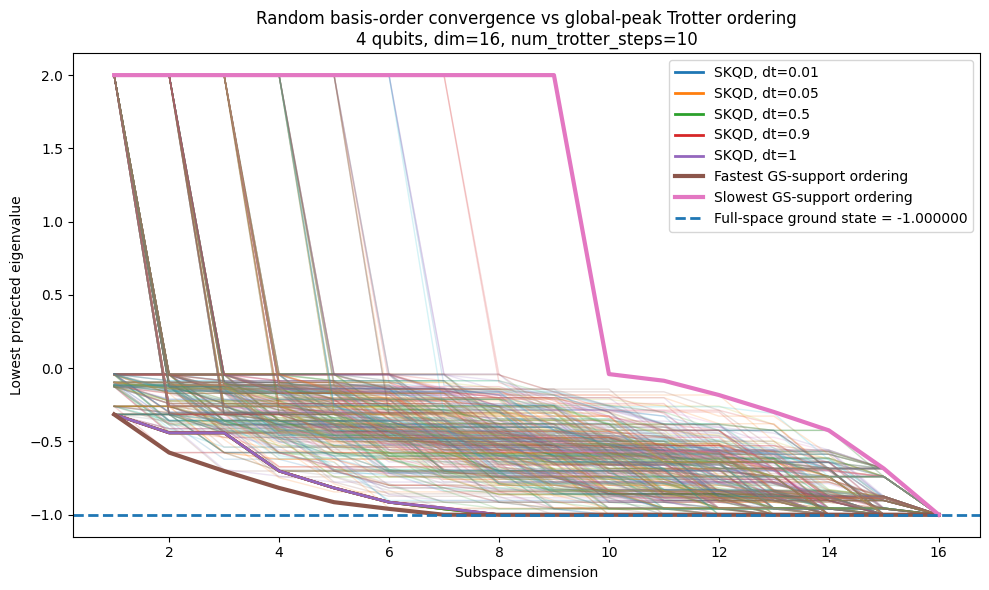

In [98]:
import itertools
import math
from typing import Iterable, List, Tuple, Dict

import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt


# ============================================================
# Random sparse Hermitian Hamiltonian
# ============================================================

def make_hermitian_sparse_random_from_qubits(
    n_qubits: int,
    density: float,
    seed: int = 42,
) -> sp.csr_matrix:
    """
    Random sparse Hermitian Hamiltonian on the computational basis
    of n_qubits, dimension 2**n_qubits.
    """
    dim = 2 ** n_qubits
    rng = np.random.default_rng(seed)

    A = sp.random(
        dim,
        dim,
        density=density,
        format="csr",
        dtype=np.complex128,
        random_state=rng,
        data_rvs=lambda n: rng.standard_normal(n) + 1j * rng.standard_normal(n),
    )

    H = A + A.conj().T
    H = 0.5 * (H + H.getH())
    return H.tocsr()


import numpy as np
import scipy.sparse as sp


def computational_bitstrings(n_qubits: int):
    return [format(i, f"0{n_qubits}b") for i in range(2 ** n_qubits)]


def make_sparse_ground_state_hamiltonian(
    n_qubits: int,
    support_size: int,
    support_indices: list[int] | None = None,
    amplitudes: np.ndarray | None = None,
    lambda0: float = -1.0,
    lambda_exc: float = 0.0,
    lambda_out: float = 2.0,
    seed: int = 42,
) -> tuple[sp.csr_matrix, np.ndarray, list[int]]:
    """
    Construct a sparse Hermitian Hamiltonian with an exactly known sparse ground state.

    Ground state support is restricted to `support_size` computational basis states.

    Parameters
    ----------
    n_qubits : int
        Number of qubits
    support_size : int
        Number of basis states with nonzero ground-state amplitude
    support_indices : list[int] or None
        Explicit support basis indices. If None, choose randomly.
    amplitudes : ndarray or None
        Complex amplitudes on the support. If None, use uniform amplitudes.
        Will be normalized automatically.
    lambda0 : float
        Ground-state eigenvalue
    lambda_exc : float
        Excited-state eigenvalue within the support block
    lambda_out : float
        Energy assigned to all basis states outside the support
    seed : int
        Random seed if support is chosen randomly

    Returns
    -------
    H : csr_matrix
        Sparse Hermitian Hamiltonian
    psi0 : ndarray
        Exact normalized ground-state vector
    support_indices : list[int]
        Indices of bitstrings in the ground-state support
    """
    dim = 2 ** n_qubits
    if support_size < 1 or support_size > dim:
        raise ValueError("support_size must satisfy 1 <= support_size <= 2^n_qubits")

    rng = np.random.default_rng(seed)

    if support_indices is None:
        support_indices = sorted(rng.choice(dim, size=support_size, replace=False).tolist())
    else:
        if len(support_indices) != support_size:
            raise ValueError("len(support_indices) must equal support_size")
        if len(set(support_indices)) != support_size:
            raise ValueError("support_indices must be unique")
        if min(support_indices) < 0 or max(support_indices) >= dim:
            raise ValueError("support_indices out of range")

    # Build target sparse ground state
    psi0 = np.zeros(dim, dtype=np.complex128)

    if amplitudes is None:
        amps = np.ones(support_size, dtype=np.complex128)
    else:
        amps = np.asarray(amplitudes, dtype=np.complex128)
        if amps.shape != (support_size,):
            raise ValueError("amplitudes must have shape (support_size,)")

    norm = np.linalg.norm(amps)
    if norm == 0:
        raise ValueError("amplitudes must not all be zero")
    amps = amps / norm

    for idx, amp in zip(support_indices, amps):
        psi0[idx] = amp

    # Sparse construction:
    # H = lambda_out * I everywhere
    # then replace support block with:
    #   H_S = lambda_exc I + (lambda0 - lambda_exc) |psi_S><psi_S|
    #
    # Since we started from lambda_out I, the support block must be corrected by:
    #   H_support_correction = H_S - lambda_out I_support
    #
    rows = []
    cols = []
    data = []

    # Start with lambda_out * I
    for i in range(dim):
        rows.append(i)
        cols.append(i)
        data.append(lambda_out)

    # Support block correction
    psi_support = amps.reshape(-1, 1)
    H_support = (
        lambda_exc * np.eye(support_size, dtype=np.complex128)
        + (lambda0 - lambda_exc) * (psi_support @ psi_support.conj().T)
    )

    # subtract lambda_out * I on support because it was already included above
    H_support -= lambda_out * np.eye(support_size, dtype=np.complex128)

    for a, i in enumerate(support_indices):
        for b, j in enumerate(support_indices):
            val = H_support[a, b]
            if abs(val) > 0:
                rows.append(i)
                cols.append(j)
                data.append(val)

    H = sp.coo_matrix((data, (rows, cols)), shape=(dim, dim), dtype=np.complex128).tocsr()
    H = 0.5 * (H + H.getH())  # numerical clean-up

    return H, psi0, support_indices

# ============================================================
# Computational basis
# ============================================================

def computational_bitstrings(n_qubits: int) -> List[str]:
    return [format(i, f"0{n_qubits}b") for i in range(2 ** n_qubits)]


# ============================================================
# Random baseline curves
# ============================================================

def permutation_iterator(
    n_states: int,
    mode: str = "sample",
    n_samples: int = 100,
    seed: int = 1234,
) -> Iterable[np.ndarray]:
    if mode == "all":
        for perm in itertools.permutations(range(n_states)):
            yield np.array(perm, dtype=int)
    elif mode == "sample":
        rng = np.random.default_rng(seed)
        base = np.arange(n_states)
        for _ in range(n_samples):
            yield rng.permutation(base)
    else:
        raise ValueError("mode must be either 'all' or 'sample'")


def convergence_curve_for_permutation_dense(
    H_dense: np.ndarray,
    perm: np.ndarray,
) -> np.ndarray:
    """
    Reorder H once by perm, then for m=1..dim compute the ground-state
    energy of the leading principal m x m block.
    """
    H_perm = H_dense[np.ix_(perm, perm)]
    dim = H_perm.shape[0]
    energies = np.empty(dim, dtype=float)

    for m in range(1, dim + 1):
        energies[m - 1] = np.linalg.eigvalsh(H_perm[:m, :m])[0]

    return energies


def all_convergence_curves_dense(
    H: sp.csr_matrix | np.ndarray,
    mode: str = "sample",
    n_samples: int = 100,
    seed: int = 1234,
) -> np.ndarray:
    H_dense = H.toarray() if sp.issparse(H) else np.asarray(H, dtype=np.complex128)
    dim = H_dense.shape[0]

    curves = []
    for perm in permutation_iterator(dim, mode=mode, n_samples=n_samples, seed=seed):
        curves.append(convergence_curve_for_permutation_dense(H_dense, perm))

    return np.vstack(curves)


def full_ground_state_energy_dense(H_dense: np.ndarray) -> float:
    return float(np.linalg.eigvalsh(H_dense)[0].real)


# ============================================================
# Generic Trotterization for sparse Hermitian H
# ============================================================

def decompose_sparse_hermitian_into_terms(H: sp.csr_matrix):
    """
    Decompose sparse Hermitian H into:
      - diagonal terms
      - 2x2 off-diagonal pair terms
    """
    H_coo = H.tocoo()
    dim = H.shape[0]

    diag_values = np.zeros(dim, dtype=np.complex128)
    pair_terms = []

    for i, j, val in zip(H_coo.row, H_coo.col, H_coo.data):
        if i == j:
            diag_values[i] = val
        elif i < j:
            pair_terms.append((i, j, val))

    return diag_values, pair_terms


def apply_diagonal_term_evolution(
    psi: np.ndarray,
    diag_values: np.ndarray,
    dt: float,
) -> np.ndarray:
    return np.exp(-1j * dt * diag_values) * psi


def apply_pair_term_evolution_inplace(
    psi: np.ndarray,
    i: int,
    j: int,
    hij: complex,
    dt: float,
) -> None:
    """
    Apply exp(-i dt H_pair) on amplitudes psi[i], psi[j], where

        H_pair = hij |i><j| + hij* |j><i|
    """
    r = abs(hij)
    if r == 0.0:
        return

    a = psi[i]
    b = psi[j]

    c = np.cos(dt * r)
    s = np.sin(dt * r)

    psi[i] = c * a - 1j * s * (hij / r) * b
    psi[j] = c * b - 1j * s * (np.conjugate(hij) / r) * a


def trotter_step_first_order(
    psi: np.ndarray,
    diag_values: np.ndarray,
    pair_terms: List[Tuple[int, int, complex]],
    dt: float,
) -> np.ndarray:
    psi_new = apply_diagonal_term_evolution(psi.copy(), diag_values, dt)

    for i, j, hij in pair_terms:
        apply_pair_term_evolution_inplace(psi_new, i, j, hij, dt)

    norm = np.linalg.norm(psi_new)
    if norm > 0:
        psi_new /= norm

    return psi_new


def trotter_evolution_record_probabilities(
    H: sp.csr_matrix,
    n_qubits: int,
    dt: float,
    num_trotter_steps: int,
    initial_basis_index: int = 0,
) -> Tuple[List[np.ndarray], List[np.ndarray]]:
    """
    Run Trotterized evolution and record:
      - statevector at t=0 and after each timestep
      - probability distribution at t=0 and after each timestep
    """
    dim = 2 ** n_qubits
    diag_values, pair_terms = decompose_sparse_hermitian_into_terms(H)

    psi = np.zeros(dim, dtype=np.complex128)
    psi[initial_basis_index] = 1.0

    states = [psi.copy()]
    probs = [np.abs(psi) ** 2]   # include t=0

    for _ in range(num_trotter_steps):
        psi = trotter_step_first_order(psi, diag_values, pair_terms, dt)
        states.append(psi.copy())
        probs.append(np.abs(psi) ** 2)

    return states, probs

# ============================================================
# Naive Ordering
# ============================================================

def quota_schedule(total_to_allocate: int, num_steps: int) -> List[int]:
    """
    Split total_to_allocate across num_steps as evenly as possible.
    Example: 15 over 4 steps -> [4, 4, 4, 3]
    """
    base = total_to_allocate // num_steps
    rem = total_to_allocate % num_steps
    return [base + (1 if t < rem else 0) for t in range(num_steps)]


def fixed_quota_order_from_trotter(
    H: sp.csr_matrix,
    n_qubits: int,
    dt: float = 0.1,
    num_trotter_steps: int = 4,
    initial_basis_index: int = 0,
    include_t0_initial_state: bool = True,
    per_step_quota: int | None = None,
    tie_break: str = "index",
) -> Tuple[np.ndarray, List[List[int]], List[np.ndarray]]:
    """
    Build an ordering by selecting a fixed number of unseen bitstrings after each Trotter step.

    Rules
    -----
    - If include_t0_initial_state=True:
        block 0 contains only the initial basis state.
        The remaining dim-1 states are distributed across the Trotter steps.
    - Otherwise:
        no explicit t=0 block is used, and all dim states are distributed
        across the evolved timesteps.

    Parameters
    ----------
    per_step_quota : int or None
        If None, use an automatic near-uniform schedule.
        If int, attempt to pick exactly this many per evolved timestep.
        If the total does not match the available number of states, the last
        step is adjusted to absorb the remainder.
    tie_break : str
        Currently only "index" is implemented; ties in probability are broken
        by ascending basis index.

    Returns
    -------
    final_order : ndarray
        concatenated ordering of all basis states
    blocks : list[list[int]]
        timestep blocks
        - if include_t0_initial_state=True, blocks[0] is the t=0 block
        - then blocks[1],...,blocks[num_trotter_steps] correspond to evolved steps
    probs_by_step : list[ndarray]
        probability distributions recorded after each evolved timestep
    """
    dim = 2 ** n_qubits
    _, probs_by_step = trotter_evolution_record_probabilities(
        H=H,
        n_qubits=n_qubits,
        dt=dt,
        num_trotter_steps=num_trotter_steps,
        initial_basis_index=initial_basis_index,
    )

    unsampled = set(range(dim))
    blocks: List[List[int]] = []

    # Optional t=0 block
    if include_t0_initial_state:
        blocks.append([initial_basis_index])
        unsampled.remove(initial_basis_index)
        total_to_allocate = dim - 1
    else:
        total_to_allocate = dim

    # Build quotas for evolved timesteps
    if per_step_quota is None:
        quotas = quota_schedule(total_to_allocate, num_trotter_steps)
    else:
        quotas = [per_step_quota] * num_trotter_steps
        allocated = sum(quotas)

        # Adjust the last timestep so the total matches exactly
        quotas[-1] += (total_to_allocate - allocated)

        if quotas[-1] < 0:
            raise ValueError(
                "per_step_quota is too large for the chosen number of steps "
                "and include_t0_initial_state setting."
            )

    # Select unseen states at each evolved timestep
    for step in range(num_trotter_steps):
        probs = probs_by_step[step]

        ranking = sorted(
            list(unsampled),
            key=lambda z: (-probs[z], z) if tie_break == "index" else (-probs[z], z),
        )

        quota = quotas[step]
        chosen = ranking[:quota]

        for z in chosen:
            unsampled.remove(z)

        blocks.append(chosen)

    # Safety fallback: append anything left over to the final block
    if unsampled:
        leftover = sorted(list(unsampled))
        blocks[-1].extend(leftover)

    final_order = np.array([z for block in blocks for z in block], dtype=int)

    if len(final_order) != dim:
        raise RuntimeError("Fixed-quota ordering does not contain all basis states.")
    if len(set(final_order.tolist())) != dim:
        raise RuntimeError("Fixed-quota ordering contains duplicates.")

    return final_order, blocks, probs_by_step



# ============================================================
# Global-over-all-timesteps ordering
# ============================================================

def global_peak_bitstring_order_from_trotter(
    H: sp.csr_matrix,
    n_qubits: int,
    dt: float = 0.1,
    num_trotter_steps: int = 4,
    initial_basis_index: int = 0,
) -> Tuple[np.ndarray, List[List[int]], np.ndarray, np.ndarray, List[np.ndarray]]:

    _, probs_by_step = trotter_evolution_record_probabilities(
        H=H,
        n_qubits=n_qubits,
        dt=dt,
        num_trotter_steps=num_trotter_steps,
        initial_basis_index=initial_basis_index,
    )

    prob_matrix = np.vstack(probs_by_step)  # shape = (num_trotter_steps + 1, dim)

    peak_steps = np.argmax(prob_matrix, axis=0)
    peak_scores = np.max(prob_matrix, axis=0)

    dim = prob_matrix.shape[1]
    n_recorded_steps = prob_matrix.shape[0]

    blocks = []
    for t in range(n_recorded_steps):   # now includes t=0
        members = [z for z in range(dim) if peak_steps[z] == t]
        members.sort(key=lambda z: (-peak_scores[z], z))
        blocks.append(members)

    final_order = np.array([z for block in blocks for z in block], dtype=int)

    return final_order, blocks, peak_scores, peak_steps, probs_by_step



#
# Upper and Lower Line!! 
#

def exact_ground_state(H: sp.csr_matrix | np.ndarray) -> Tuple[float, np.ndarray]:
    """
    Return the exact ground-state eigenvalue and eigenvector of H.
    """
    H_dense = H.toarray() if sp.issparse(H) else np.asarray(H, dtype=np.complex128)
    evals, evecs = np.linalg.eigh(H_dense)
    e0 = float(evals[0].real)
    psi0 = evecs[:, 0]
    return e0, psi0


def ground_state_support_orderings(
    H: sp.csr_matrix | np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Construct the fastest and slowest basis-state orderings according to
    computational-basis support in the exact ground state.

    Returns
    -------
    fastest_order : ndarray
        basis indices sorted by descending ground-state support
    slowest_order : ndarray
        basis indices sorted by ascending ground-state support
    weights : ndarray
        weights[z] = |<z|psi0>|^2
    psi0 : ndarray
        exact ground-state vector
    """
    e0, psi0 = exact_ground_state(H)
    weights = np.abs(psi0) ** 2

    # Stable tie-breaking by basis index
    basis = np.arange(len(weights))

    fastest_order = np.array(
        sorted(basis, key=lambda z: (-weights[z], z)),
        dtype=int,
    )

    slowest_order = np.array(
        sorted(basis, key=lambda z: (weights[z], z)),
        dtype=int,
    )

    return fastest_order, slowest_order, weights, psi0

def projected_ground_energy_from_indices(H_dense: np.ndarray, indices: list[int]) -> float:
    """
    Lowest eigenvalue of H projected onto the span of the computational
    basis states in `indices`.
    """
    subH = H_dense[np.ix_(indices, indices)]
    return float(np.linalg.eigvalsh(subH)[0].real)


def greedy_oracle_ordering(
    H: sp.csr_matrix | np.ndarray,
    mode: str = "best",
) -> tuple[np.ndarray, np.ndarray]:
    """
    Greedy oracle ordering with respect to the actual convergence objective.

    mode="best":
        at each step choose the next bitstring that gives the LOWEST projected
        ground-state energy after adding it.

    mode="worst":
        at each step choose the next bitstring that gives the HIGHEST projected
        ground-state energy after adding it.

    Returns
    -------
    order : ndarray
        greedy ordering of basis indices
    curve : ndarray
        corresponding convergence curve
    """
    H_dense = H.toarray() if sp.issparse(H) else np.asarray(H, dtype=np.complex128)
    dim = H_dense.shape[0]

    selected = []
    remaining = list(range(dim))
    curve = []

    for _ in range(dim):
        best_candidate = None
        best_value = None

        for z in remaining:
            trial = selected + [z]
            e_trial = projected_ground_energy_from_indices(H_dense, trial)

            if best_candidate is None:
                best_candidate = z
                best_value = e_trial
            else:
                if mode == "best":
                    # lower projected energy = faster convergence
                    if e_trial < best_value - 1e-12 or (
                        abs(e_trial - best_value) <= 1e-12 and z < best_candidate
                    ):
                        best_candidate = z
                        best_value = e_trial
                elif mode == "worst":
                    # higher projected energy = slower convergence
                    if e_trial > best_value + 1e-12 or (
                        abs(e_trial - best_value) <= 1e-12 and z < best_candidate
                    ):
                        best_candidate = z
                        best_value = e_trial
                else:
                    raise ValueError("mode must be 'best' or 'worst'")

        selected.append(best_candidate)
        remaining.remove(best_candidate)
        curve.append(best_value)

    return np.array(selected, dtype=int), np.array(curve, dtype=float)


# ============================================================
# Plotting
# ============================================================

def summarize_blocks(blocks, bitstrings=None, include_members=False, start_at_t0=True):
    """
    Summarize how many bitstrings are assigned to each timestep block.

    Parameters
    ----------
    blocks : list[list[int]]
        blocks[t] contains basis-state indices assigned to timestep t
    bitstrings : list[str] or None
        optional computational-basis labels
    include_members : bool
        if True, also include the actual basis indices / bitstrings
    start_at_t0 : bool
        if True, label blocks as t=0,1,2,... ; otherwise 1,2,3,...

    Returns
    -------
    summary : list[dict]
    """
    summary = []
    offset = 0 if start_at_t0 else 1

    for t, block in enumerate(blocks):
        entry = {
            "step": t + offset,
            "count": len(block),
        }
        if include_members:
            entry["indices"] = list(block)
            if bitstrings is not None:
                entry["bitstrings"] = [bitstrings[i] for i in block]
        summary.append(entry)

    return summary


def print_block_summary(blocks, bitstrings=None, include_members=False, start_at_t0=True):
    summary = summarize_blocks(
        blocks,
        bitstrings=bitstrings,
        include_members=include_members,
        start_at_t0=start_at_t0,
    )

    print("Bitstring-assignment summary:")
    for row in summary:
        print(f"  step {row['step']}: {row['count']} bitstrings")
        if include_members:
            print(f"    indices    : {row['indices']}")
            if bitstrings is not None:
                print(f"    bitstrings : {row['bitstrings']}")





def plot_convergence_curves_with_global_trotter_order(
    random_curves: np.ndarray,
    skqd_curves: list[np.ndarray],
    e0_full: float,
    fastest_curve: np.ndarray, 
    slowest_curve: np.ndarray,
    title: str,
    alpha_random: float = 0.15,
    timesteps: list = None,
    yscale='linear',
):
    x = np.arange(1, random_curves.shape[1] + 1)

    plt.figure(figsize=(10, 6))

    if yscale=='log': 
        transform = lambda y: np.maximum(y - e0_full, 1e-14)
        ylabel = "Energy error  E - E₀"
    else: 
        transform = lambda y: y
        ylabel = "Lowest projected eigenvalue"

    for i in range(random_curves.shape[0]):
        plt.plot(x, transform(random_curves[i]), alpha=alpha_random, linewidth=1)

    for i in range(len(skqd_curves)):
        guided_curve = skqd_curves[i]
        plt.plot(
            x,
            transform(guided_curve),
            linewidth=2,
            label= f"SKQD, dt={timesteps[i]}" if timesteps is not None else "SKQD",
        )

    plt.plot(x, transform(fastest_curve), linewidth=3.0, label="Fastest GS-support ordering")
    plt.plot(x, transform(slowest_curve), linewidth=3.0, label="Slowest GS-support ordering")

    if yscale!='log':
        plt.axhline(
            e0_full,
            linestyle="--",
            linewidth=2,
            label=f"Full-space ground state = {e0_full:.6f}",
        )

    plt.xlabel("Subspace dimension")
    plt.ylabel(ylabel)
    plt.title(title)

    if yscale == 'log': 
        plt.yscale('log')
    elif yscale == 'symlog':
        plt.yscale('symlog')

    if yscale == 'log' or yscale == 'symlog':
        plt.ylim(1e-3, e0_full)

    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Example usage
# ============================================================

if __name__ == "__main__":
    # --------------------------------------------------------
    # Parameters
    # --------------------------------------------------------
    n_qubits = 4
    density = 0.1
    hamiltonian_seed = 50

    # Baseline random curves
    n_samples = 500
    permutation_seed = 123

    # Trotter / ordering parameters
    dt = 0.1
    num_trotter_steps = 10
    initial_basis_index = 5  # |0101>

    # --------------------------------------------------------
    # Build Hamiltonian and basis
    # --------------------------------------------------------
    # H = make_hermitian_sparse_random_from_qubits(
    #     n_qubits=n_qubits,
    #     density=density,
    #     seed=hamiltonian_seed,
    # )

    support_size = 7
    amplitudes = np.random.rand(support_size).astype(np.complex128)

    H, psi0, support_indices = make_sparse_ground_state_hamiltonian(
        n_qubits=n_qubits,
        support_size=support_size,
        amplitudes=amplitudes,
        seed=42,
        lambda0=-1.0,
        lambda_exc=0.0,
        lambda_out=2.0,
    )
    H_dense = H.toarray()
    bitstrings = computational_bitstrings(n_qubits)

    # --------------------------------------------------------
    # Random baseline curves
    # --------------------------------------------------------
    random_curves = all_convergence_curves_dense(
        H_dense,
        mode="sample",
        n_samples=n_samples,
        seed=permutation_seed,
    )

    # --------------------------------------------------------
    # New global-over-all-timesteps ordering
    # --------------------------------------------------------
    
    # global_order, global_blocks, peak_scores, peak_steps, probs_by_step = (
    #     global_peak_bitstring_order_from_trotter(
    #         H=H,
    #         n_qubits=n_qubits,
    #         dt=dt,
    #         num_trotter_steps=num_trotter_steps,
    #         initial_basis_index=initial_basis_index,
    #     )
    # )
    skqd_curves = []

    dt_list = [0.01, 0.05, 0.5, 0.9, 1]
    for dt in dt_list:
        # global_order, global_blocks, peak_scores, peak_steps, probs_by_step = (
        #     global_peak_bitstring_order_from_trotter(
        #         H=H,
        #         n_qubits=n_qubits,
        #         dt=dt,
        #         num_trotter_steps=num_trotter_steps,
        #         initial_basis_index=initial_basis_index,
        #     )
        # )

        global_order, global_blocks, probs_by_step = fixed_quota_order_from_trotter(
            H=H,
            n_qubits=n_qubits,
            dt=dt,
            num_trotter_steps=num_trotter_steps,
            initial_basis_index=0,
            include_t0_initial_state=True,
            per_step_quota=None,   # automatic schedule
        )

        print_block_summary(global_blocks, bitstrings=bitstrings, include_members=True, start_at_t0=True)

        guided_curve = convergence_curve_for_permutation_dense(H_dense, global_order)
        skqd_curves.append(guided_curve)

    e0_full = full_ground_state_energy_dense(H_dense)

    # Exact full-space ground state
    e0_full, psi0 = exact_ground_state(H_dense)

    # Best / worst possible orderings based on exact GS support
    # fastest_order, slowest_order, gs_weights, psi0 = ground_state_support_orderings(H_dense)

    # # Their convergence curves
    # fastest_curve = convergence_curve_for_permutation_dense(H_dense, fastest_order)
    # slowest_curve = convergence_curve_for_permutation_dense(H_dense, slowest_order)

    fastest_order, fastest_curve = greedy_oracle_ordering(H_dense, mode="best")
    slowest_order, slowest_curve = greedy_oracle_ordering(H_dense, mode="worst")

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------
    plot_convergence_curves_with_global_trotter_order(
        random_curves=random_curves,
        skqd_curves=skqd_curves,
        e0_full=e0_full,
        slowest_curve=slowest_curve,
        fastest_curve=fastest_curve,
        title=(
            f"Random basis-order convergence vs global-peak Trotter ordering\n"
            f"{n_qubits} qubits, dim={2**n_qubits}, "
            f"num_trotter_steps={num_trotter_steps}"
        ),
        alpha_random=0.18,
        timesteps=dt_list,
        yscale='linear'
    )

In [92]:
evals, evecs = np.linalg.eigh(H.toarray())
e0 = evals[0]
psi_exact = evecs[:, 0]

print("Exact ground-state energy:", e0)
print("Target ground-state energy:", -1.0)

# Compare up to a global phase
overlap = np.vdot(psi0, psi_exact)
print("Ground-state overlap magnitude:", abs(overlap))

Exact ground-state energy: -1.0000000000000004
Target ground-state energy: -1.0
Ground-state overlap magnitude: 1.0000000000000007


In [ ]:
N = 18
print(f'full Hilbert space dimension: {(math.comb(N, N // 2))}')